# Toxic Comments Classification - SVM

#### Author: SAFAA ENNACIRI - ENNS11538307                                 
#### Research Director: M. HAKIM LOUNIS

Dataset: Anti-Asian Hate in Social Media during the COVID-19 Crisis. It is avaialble at http://claws.cc.gatech.edu/covid/#dataset.


The comments are divided in two classes: toxic and normal.

Algorithme used: SVC

Preprocessing techniques used:
* Convert text to lowercase
* Remove special caracters and numbers 
* Remove stop words
* Tokenization (accept all kind of tokens except spaces (carriage returns, line breaks, tabs and multiple spaces))

# 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn import metrics
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate, cross_val_predict
from matplotlib import pyplot as plt 
import seaborn as sns
import pickle
import openpyxl 
from openpyxl import Workbook
from openpyxl.styles import Alignment
from openpyxl.styles.borders import Border, Side
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import re

# 2. Data Preparation 

In [2]:
# Load training data
df = pd.read_csv('../../Data/train_set3.csv')
df.head()

,Tweet ID,Text,tox
0,1230482808457527297,BREAKING: Many leading Chinese scientists are ...,0.0
1,1244980592615116800,"If China can kill us, they can kill you too @A...",1.0
2,1244899032771604480,Fuck u Chi Na!!! Karma is coming soon !!! The ...,1.0
3,1244895530720710656,Some Chinese are horrible as fuck! #ChinaLiedP...,1.0
4,1244341105879142407,"@ScottGottliebMD you are a ""doctor"" and you be...",1.0


In [3]:
# Load testing data
test = pd.read_csv('../../Data/test_set3.csv')
test.head()

,Tweet ID,Text,tox
0,1230469201325895691,@BangizweNkosi @alfred_cabonena #Commies the s...,1.0
1,1245286806330806273,@LeeooZeng @ChinaDaily Mother Fucking #chinese...,1.0
2,1245502582593912833,@argyleumbrella @business Yep. Fucking MONTHS ...,1.0
3,1230388499792220163,To all the Xbots that couldn’t control your fa...,0.0
4,1241063784501915648,@realDonaldTrump This is the most racist and u...,0.0


# 3. Preprocessing

In [4]:
stop_words = set(stopwords.words('english'))

In [5]:
print(stop_words)

{'shouldn', 'further', 'but', 'haven', 'was', "she's", 'ain', 'no', "wouldn't", 'few', 'for', 'mustn', 'most', 'until', 'me', 'having', 'very', 'hasn', 'all', 'while', 'needn', 'in', 'himself', 'you', 'themselves', 'if', 'each', 'o', 'him', 'his', "doesn't", 'yourself', 'he', "hadn't", 'be', 'them', 're', "couldn't", "haven't", 's', 'yourselves', 'why', 'too', 'she', 'our', 'at', 'when', 'hers', 'under', 'on', 'mightn', 'below', 'over', 'any', "shan't", 'they', 'after', 'ma', 'don', 'about', "mightn't", "should've", 'those', 'does', "didn't", 'up', 'how', 'herself', 'with', 'down', 'then', 'myself', "mustn't", 'aren', 'ourselves', 'theirs', 'an', 'before', 'their', 'we', "it's", 'her', 'were', 'where', 'into', "don't", 'y', 'being', 'above', 'only', 'and', 'do', 'these', 'have', 'because', 'again', 'some', 'so', 'doesn', 'weren', 'couldn', 'more', 'hadn', 'what', 'same', 'as', 'been', 'between', 'through', 'other', 'shan', 'by', 'not', 'yours', 'just', 'itself', 'once', 'here', 'there'

In [6]:
def clean_text(comment): 

    comment = comment.lower() # Normalize to lowercase 
    comment = re.sub(r'[^a-zA-Z]', ' ',comment) # remove special caracters and nuumbers 
    comment = re.sub(r'[“”¨«»®´·º½¾¿¡§£₤‘’]', ' ', comment) # Remove special characters
    word_tokens = comment.split(' ') #word_tokenize(comment)
    
    filtered_comment = []  
    # converts the words in word_tokens tand tchecks whether 
    #they are present in stop_words or not
    for w in word_tokens:
        if w not in stop_words:
            filtered_comment.append(w)

    comment = (" ").join(filtered_comment)
    
    return comment

In [7]:
# clean and normalize comments
df['Text'] = df['Text'].map(lambda word:clean_text(word))
test['Text'] = test['Text'].map(lambda word:clean_text(word))

In [8]:
x_train = df['Text']
y_train = df['tox']

#Check shape of data
print(x_train.shape)
print(y_train.shape)

(2104,)
(2104,)


In [9]:
X_test = test['Text']
Y_test = test['tox']

#Check shape of data
print(X_test.shape)
print(Y_test.shape)

(527,)
(527,)


# 3. Classifier training (SVC)

### Create pipeline

In [10]:
# create a pipeline
SVC_pipeline = Pipeline([
                ('tfidf', TfidfVectorizer(lowercase=False, 
                                          token_pattern=r'\S+', max_features=20000)),
                ('clf', SVC(kernel='rbf', C=1, gamma='scale'))
            ])

### Train classifier

In [11]:
# cross validation
metrics = ['accuracy', 'recall', 'f1', 'precision']
result = cross_validate (SVC_pipeline, x_train, y_train, cv=5, scoring = metrics,  return_estimator=True)

In [12]:
# save models
svc_fit = result['estimator']
i = 0
for model in svc_fit:
    dir_name = "models/Set3_approach#4_" + str(i) + ".sav"
    pickle.dump(model, open(dir_name, 'wb'))
    i = i + 1

### Evaluate metrics

In [13]:
# Model Evaluation metrics for train data
train_accuracy = "%.4f" % (result['test_accuracy'].mean())
train_recall  = "%.4f" % (result['test_recall'].mean())
train_F1_score  = "%.4f" % (result['test_f1'].mean())
train_precision  = "%.4f" % (result['test_precision'].mean())

# Print scores for evaluation metrics
print('Results for train data')
print ('-----------------------')
print('Accuracy score : ', train_accuracy)
print('recall : ', train_recall)
print('F1_score : ' , train_F1_score)
print('precision : ' , train_precision)

Results for train data
-----------------------
Accuracy score :  0.9354
recall :  0.9384
F1_score :  0.9338
precision :  0.9294


# 4. Predictions

### Test set

In [14]:
# predict test data
preds_test = cross_val_predict(SVC_pipeline, X_test, Y_test, cv=5)

In [15]:
# svm Confusion matrix
print('\n confusion matrix for test data \n')
print((confusion_matrix(Y_test, preds_test)))


 confusion matrix for test data 

[[224  39]
 [ 65 199]]


In [16]:
# svm classification report
print('\n\n classification report for test data \n')
print(classification_report(Y_test, preds_test, target_names=['normal','toxic']))



 classification report for test data 

              precision    recall  f1-score   support

      normal       0.78      0.85      0.81       263
       toxic       0.84      0.75      0.79       264

    accuracy                           0.80       527
   macro avg       0.81      0.80      0.80       527
weighted avg       0.81      0.80      0.80       527



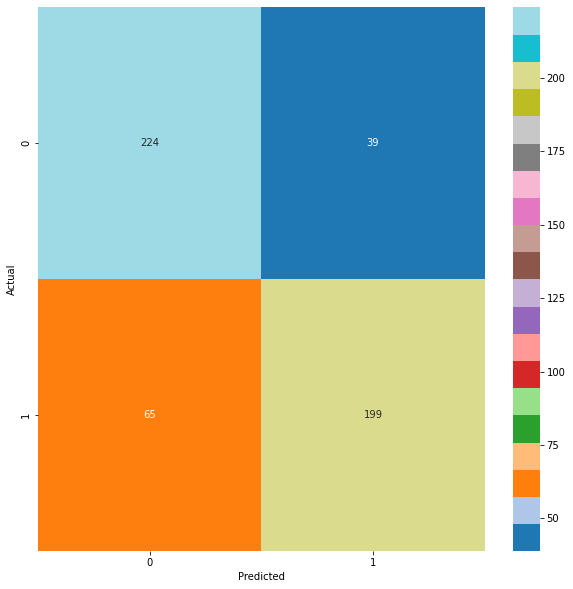

In [17]:
# plot confusion matrix
conf_mat = confusion_matrix(Y_test, preds_test)
fig, ax = plt.subplots(figsize=(10,10))
cmap = "tab20"
sns.heatmap(conf_mat, annot=True, fmt='d',cmap=cmap)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [18]:
# Model Evaluation metrics for test data
test_accuracy = "%.4f" % (accuracy_score(Y_test, preds_test))
test_recall  = "%.4f" % (recall_score(Y_test, preds_test))
test_F1_score  = "%.4f" % (f1_score(Y_test, preds_test))
test_precision  = "%.4f" % (precision_score(Y_test, preds_test))

# Print scores for evaluation metrics
print('Results for test data')
print ('-----------------------')
print('Accuracy score : ', test_accuracy)
print('recall : ', test_recall)
print('F1_score : ' , test_F1_score)
print('precision : ' , test_precision)

Results for test data
-----------------------
Accuracy score :  0.8027
recall :  0.7538
F1_score :  0.7928
precision :  0.8361


# 5. Save results to Excel file

In [19]:
# define tarjet
newFile = "../results_set3.xlsx"

# open excel file
workbook = openpyxl.load_workbook(filename = newFile)        
worksheet = workbook.active
    
# scores for evaluation metrics
data = {1:'Approach #4', 2:train_accuracy, 3:train_recall, 4:train_F1_score, 5:train_precision, 
                  6:test_accuracy, 7:test_recall, 8:test_F1_score, 9:test_precision}

# row's index for approach
index = 6

# delete row of approach
worksheet.delete_rows(index, 1)

# insert data in excel sheet
worksheet.insert_rows(index)
for col, value in data.items():
    worksheet.cell(row=index, column=col, value=value)
    
# define style border
thin_border = Border(left=Side(style='thin'), 
                     right=Side(style='thin'), 
                     top=Side(style='thin'), 
                     bottom=Side(style='thin'))
cell_alignment = Alignment(horizontal='center')

# apply style border
for row in worksheet:
    for cell in row:
        cell.border = thin_border
        cell.alignment = cell_alignment
    
# save file
workbook.save(newFile)